In [ ]:
!pip install thop timm -q

In [ ]:
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import timm
from thop import profile as thop_profile
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support, accuracy_score
)

os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB


## 1 — Data Preparation

CIFAR-10 setup  with **45K/5K/10K** train/val/test split.

In [ ]:
#  Transforms
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

#  Splits
full_train = datasets.CIFAR10(root="data/", train=True, download=True, transform=transform_train)
# For val set, we need test-time transforms (no augmentation)
full_train_val = datasets.CIFAR10(root="data/", train=True, download=True, transform=transform_test)

# Stratified-ish split via seeded random_split (45K train, 5K val)
g = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(len(full_train)), [45000, 5000], generator=g)

train_set = torch.utils.data.Subset(full_train, train_idx.indices)
val_set   = torch.utils.data.Subset(full_train_val, val_idx.indices)
test_set  = datasets.CIFAR10(root="data/", train=False, download=True, transform=transform_test)

BS = 128
train_loader = DataLoader(train_set, batch_size=BS, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set, batch_size=BS, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=BS, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = test_set.classes
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Batch size: {BS} | Classes: {CLASS_NAMES}")

100%|██████████| 170M/170M [00:03<00:00, 47.7MB/s]


Train: 45000 | Val: 5000 | Test: 10000
Batch size: 128 | Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2 — Model Definitions

Three candidates with different inductive biases:
- **SimpleCNN**: Locality only, no skip connections — baseline
- **ResNet-18**: Locality + residual connections — strong gradient flow for adversarial analysis
- **ViT-Tiny**: Global self-attention — patch-based, different adversarial vulnerability profile

In [ ]:
# Candidate 1: SimpleCNN (baseline)
class SimpleCNN(nn.Module):
    """4-layer CNN baseline: 2 conv blocks + 2 FC layers."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 -> 64
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
            # Block 2: 64 -> 128
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Candidate 2: ResNet-18 (CIFAR-adapted)
def build_resnet18(num_classes=10):
    """ResNet-18 adapted for 32x32: 3x3 conv1."""
    model = models.resnet18(weights=None, num_classes=num_classes)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model


# Candidate 3: ViT-Tiny (via timm)
def build_vit_tiny(num_classes=10):
    """ViT-Tiny adapted for 32x32 CIFAR-10: patch_size=4, img_size=32."""
    model = timm.create_model(
        'vit_tiny_patch16_224',
        pretrained=False,
        num_classes=num_classes,
        img_size=32,
        patch_size=4,
    )
    return model


# Build all three
candidates = {
    "SimpleCNN":  SimpleCNN().to(device),
    "ResNet18":   build_resnet18().to(device),
    "ViT-Tiny":   build_vit_tiny().to(device),
}

# Parameter counts & FLOPs
dummy = torch.randn(1, 3, 32, 32).to(device)
print(f"{'Model':<12} {'Params':>10} {'FLOPs':>12}")
print("=" * 38)
model_meta = {}
for name, m in candidates.items():
    params = sum(p.numel() for p in m.parameters())
    flops, _ = thop_profile(m, inputs=(dummy,), verbose=False)
    model_meta[name] = {"params": params, "flops": flops}
    print(f"{name:<12} {params:>10,} {flops:>12,.0f}")

Model            Params        FLOPs
SimpleCNN     2,360,906   99,027,456
ResNet18     11,173,962  557,889,024
ViT-Tiny      5,362,762  345,638,784


## 3 — Training Loop (All Three Models)

Each model trains for **20 epochs** with:
- SGD (lr=0.1, momentum=0.9, weight_decay=5e-4)
- Cosine annealing LR scheduler
- CrossEntropyLoss

Logging train loss, train acc, val loss, val acc per epoch + wall-clock time.

In [ ]:
EPOCHS = 20

def train_and_evaluate(model, name, train_loader, val_loader, epochs=EPOCHS):
    """Train model, return history dict with per-epoch metrics + timing."""
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
               "epoch_time": [], "lr": []}

    torch.cuda.reset_peak_memory_stats() if device.type == "cuda" else None
    total_start = time.time()

    for epoch in range(epochs):
        ep_start = time.time()

        #  Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, pred = out.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        #  Validate
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                v_loss += criterion(out, labels).item() * images.size(0)
                _, pred = out.max(1)
                v_total += labels.size(0)
                v_correct += pred.eq(labels).sum().item()

        val_loss = v_loss / v_total
        val_acc = v_correct / v_total

        scheduler.step()
        ep_time = time.time() - ep_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(ep_time)
        history["lr"].append(scheduler.get_last_lr()[0])

        print(f"  [{name}] Epoch {epoch+1:2d}/{epochs} | "
              f"Loss: {train_loss:.4f} | Acc: {100*train_acc:.1f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {100*val_acc:.1f}% | "
              f"{ep_time:.1f}s")

    total_time = time.time() - total_start
    peak_vram = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0

    history["total_time"] = total_time
    history["peak_vram_mb"] = peak_vram
    history["best_val_acc"] = max(history["val_acc"])

    # Save checkpoint
    ckpt_path = f"outputs/models/{name.lower().replace('-','_')}_cifar10.pth"
    torch.save(model.state_dict(), ckpt_path)
    history["ckpt_path"] = ckpt_path
    history["ckpt_size_mb"] = os.path.getsize(ckpt_path) / 1024**2

    print(f"\n  [{name}] Done — {total_time:.1f}s total | Best Val Acc: {100*history['best_val_acc']:.2f}% "
          f"| Peak VRAM: {peak_vram:.0f} MB | Checkpoint: {history['ckpt_size_mb']:.1f} MB\n")

    return history

In [ ]:
# Train all three candidates
all_histories = {}

for name, model in candidates.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    all_histories[name] = train_and_evaluate(model, name, train_loader, val_loader)


Training: SimpleCNN
  [SimpleCNN] Epoch  1/20 | Loss: 2.3116 | Acc: 10.7% | Val Loss: 2.3052 | Val Acc: 9.4% | 32.2s
  [SimpleCNN] Epoch  2/20 | Loss: 2.2664 | Acc: 12.2% | Val Loss: 2.1066 | Val Acc: 19.5% | 17.3s
  [SimpleCNN] Epoch  3/20 | Loss: 2.0456 | Acc: 20.9% | Val Loss: 1.8064 | Val Acc: 31.9% | 17.4s
  [SimpleCNN] Epoch  4/20 | Loss: 1.8448 | Acc: 29.0% | Val Loss: 1.5301 | Val Acc: 42.6% | 18.3s
  [SimpleCNN] Epoch  5/20 | Loss: 1.6852 | Acc: 37.1% | Val Loss: 1.4601 | Val Acc: 46.4% | 17.5s
  [SimpleCNN] Epoch  6/20 | Loss: 1.5630 | Acc: 42.3% | Val Loss: 1.2418 | Val Acc: 54.5% | 19.1s
  [SimpleCNN] Epoch  7/20 | Loss: 1.4728 | Acc: 46.2% | Val Loss: 1.1626 | Val Acc: 58.3% | 19.0s
  [SimpleCNN] Epoch  8/20 | Loss: 1.3872 | Acc: 50.0% | Val Loss: 1.1100 | Val Acc: 60.7% | 17.7s
  [SimpleCNN] Epoch  9/20 | Loss: 1.3149 | Acc: 52.9% | Val Loss: 0.9730 | Val Acc: 64.6% | 17.9s
  [SimpleCNN] Epoch 10/20 | Loss: 1.2511 | Acc: 55.2% | Val Loss: 0.9582 | Val Acc: 66.4% | 17.6s


## 4 — Learning Curves

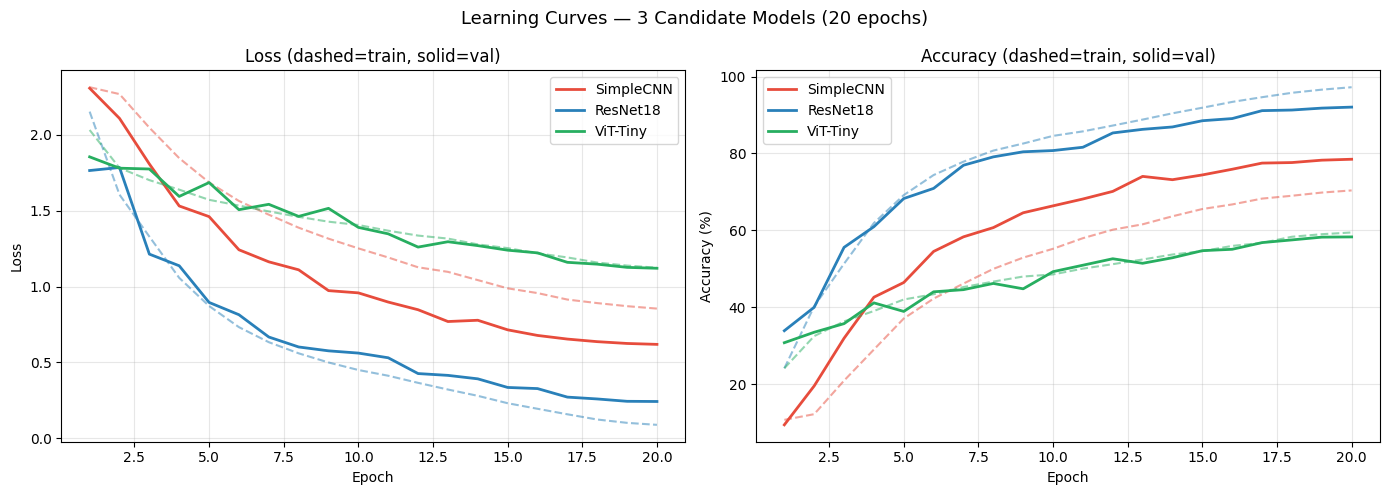

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"SimpleCNN": "#e74c3c", "ResNet18": "#2980b9", "ViT-Tiny": "#27ae60"}

for name, h in all_histories.items():
    epochs_range = range(1, EPOCHS + 1)
    axes[0].plot(epochs_range, h["train_loss"], '--', color=colors[name], alpha=0.5)
    axes[0].plot(epochs_range, h["val_loss"], '-', color=colors[name], label=f"{name}", linewidth=2)
    axes[1].plot(epochs_range, [a*100 for a in h["train_acc"]], '--', color=colors[name], alpha=0.5)
    axes[1].plot(epochs_range, [a*100 for a in h["val_acc"]], '-', color=colors[name], label=f"{name}", linewidth=2)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss (dashed=train, solid=val)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy (dashed=train, solid=val)"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Learning Curves — 3 Candidate Models (20 epochs)", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/learning_curves_comparison.png", dpi=150)
plt.show()

## 5 — Test Set Evaluation (Classification Metrics)

In [ ]:
def evaluate_classification(model, name, loader):
    """Full classification metrics on test set."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            _, preds = logits.max(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    auroc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    print(f"\n{'='*60}")
    print(f"{name} — Test Set Metrics")
    print(f"{'='*60}")
    print(f"  Accuracy:        {100*acc:.2f}%")
    print(f"  Precision (mac): {100*prec:.2f}%")
    print(f"  Recall (mac):    {100*rec:.2f}%")
    print(f"  F1 (macro):      {100*f1:.2f}%")
    print(f"  AUROC (macro):   {auroc:.4f}")
    print(f"\nPer-class report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

    return {"accuracy": acc, "precision_macro": prec, "recall_macro": rec,
            "f1_macro": f1, "auroc_macro": auroc, "labels": all_labels,
            "preds": all_preds, "probs": all_probs}

test_results = {}
for name, model in candidates.items():
    test_results[name] = evaluate_classification(model, name, test_loader)


SimpleCNN — Test Set Metrics
  Accuracy:        77.73%
  Precision (mac): 77.63%
  Recall (mac):    77.73%
  F1 (macro):      77.49%
  AUROC (macro):   0.9733

Per-class report:
              precision    recall  f1-score   support

    airplane      0.822     0.778     0.799      1000
  automobile      0.911     0.906     0.908      1000
        bird      0.725     0.559     0.631      1000
         cat      0.607     0.580     0.593      1000
        deer      0.738     0.767     0.752      1000
         dog      0.673     0.695     0.684      1000
        frog      0.748     0.869     0.804      1000
       horse      0.817     0.824     0.821      1000
        ship      0.895     0.881     0.888      1000
       truck      0.828     0.914     0.869      1000

    accuracy                          0.777     10000
   macro avg      0.776     0.777     0.775     10000
weighted avg      0.776     0.777     0.775     10000


ResNet18 — Test Set Metrics
  Accuracy:        91.81%
  Preci

## 6. Adversarial Robustness Comparison

 FGSM and PGD (eps=0.02, 0.08) on all three models.  
This directly tests how each architecture responds to gradient-based attacks.

Attack methods from Milestone 1, with the **clamping fix** (valid normalized range).

In [ ]:
# Compute valid pixel range after normalization
CIFAR_MIN = torch.tensor([(0 - m) / s for m, s in zip(CIFAR_MEAN, CIFAR_STD)]).view(1, 3, 1, 1).to(device)
CIFAR_MAX = torch.tensor([(1 - m) / s for m, s in zip(CIFAR_MEAN, CIFAR_STD)]).view(1, 3, 1, 1).to(device)

def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)
    loss = nn.CrossEntropyLoss()(model(images), labels)
    model.zero_grad()
    loss.backward()
    adv = images + epsilon * images.grad.sign()
    adv = torch.max(torch.min(adv, CIFAR_MAX), CIFAR_MIN)  # clamp to valid range
    return adv.detach()

def pgd_attack(model, images, labels, epsilon, alpha=0.005, steps=10):
    orig = images.clone().detach().to(device)
    labels = labels.to(device)
    adv = orig + torch.empty_like(orig).uniform_(-epsilon, epsilon)
    adv = torch.max(torch.min(adv, CIFAR_MAX), CIFAR_MIN)

    for _ in range(steps):
        adv.requires_grad_(True)
        loss = nn.CrossEntropyLoss()(model(adv), labels)
        model.zero_grad()
        loss.backward()
        adv = adv.detach() + alpha * adv.grad.sign()
        # Project back into eps-ball AND valid range
        adv = orig + torch.clamp(adv - orig, -epsilon, epsilon)
        adv = torch.max(torch.min(adv, CIFAR_MAX), CIFAR_MIN)

    return adv.detach()

print("Attack functions ready (with normalized-range clamping)")

Attack functions ready (with normalized-range clamping)


In [ ]:
EPSILONS = [0.02, 0.08]
ATTACKS = [("fgsm", fgsm_attack), ("pgd", pgd_attack)]

adv_results = {}  # {model_name: {(atk, eps): {adv_acc, asr, conf_drop, ...}}}

for model_name, model in candidates.items():
    model.eval()
    adv_results[model_name] = {}

    print(f"\n{'='*60}")
    print(f"Attacking: {model_name}")
    print(f"{'='*60}")

    # Get clean accuracy first
    clean_correct = 0
    clean_total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            _, preds = model(images).max(1)
        clean_correct += preds.eq(labels).sum().item()
        clean_total += labels.size(0)
    clean_acc = clean_correct / clean_total

    for atk_name, atk_fn in ATTACKS:
        for eps in EPSILONS:
            t0 = time.time()
            total_samples = 0
            adv_correct = 0
            flipped = 0
            conf_clean_sum = 0.0
            conf_adv_sum = 0.0
            class_flipped = np.zeros(10)
            class_total = np.zeros(10)

            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                bs = images.size(0)

                # Clean predictions
                with torch.no_grad():
                    clean_probs = F.softmax(model(images), dim=1)
                    clean_conf, clean_pred = clean_probs.max(1)

                # Adversarial
                adv_images = atk_fn(model, images, labels, eps)
                with torch.no_grad():
                    adv_probs = F.softmax(model(adv_images), dim=1)
                    adv_conf, adv_pred = adv_probs.max(1)

                adv_correct += adv_pred.eq(labels).sum().item()
                flipped += (clean_pred != adv_pred).sum().item()
                conf_clean_sum += clean_conf.sum().item()
                conf_adv_sum += adv_conf.sum().item()
                total_samples += bs

                for c in range(10):
                    mask = labels == c
                    class_total[c] += mask.sum().item()
                    class_flipped[c] += ((clean_pred != adv_pred) & mask).sum().item()

            adv_acc = adv_correct / total_samples
            asr = flipped / total_samples
            conf_drop = (conf_clean_sum - conf_adv_sum) / total_samples
            class_asr = class_flipped / np.maximum(class_total, 1)
            elapsed = time.time() - t0

            result = {
                "clean_acc": clean_acc,
                "adv_acc": adv_acc,
                "accuracy_drop": clean_acc - adv_acc,
                "asr": asr,
                "confidence_drop": conf_drop,
                "worst_class_asr": class_asr.max(),
                "best_class_asr": class_asr.min(),
                "attack_time_s": elapsed,
            }
            adv_results[model_name][(atk_name, eps)] = result

            print(f"  {atk_name.upper()} eps={eps:.2f} | Adv Acc: {100*adv_acc:.1f}% | "
                  f"ASR: {100*asr:.1f}% | Conf Drop: {conf_drop:.3f} | "
                  f"Worst Class ASR: {100*class_asr.max():.1f}% | {elapsed:.1f}s")


Attacking: SimpleCNN
  FGSM eps=0.02 | Adv Acc: 50.0% | ASR: 30.6% | Conf Drop: 0.066 | Worst Class ASR: 43.9% | 3.5s
  FGSM eps=0.08 | Adv Acc: 12.6% | ASR: 71.2% | Conf Drop: 0.085 | Worst Class ASR: 80.3% | 3.3s
  PGD eps=0.02 | Adv Acc: 44.1% | ASR: 37.6% | Conf Drop: 0.051 | Worst Class ASR: 53.3% | 19.7s
  PGD eps=0.08 | Adv Acc: 16.5% | ASR: 67.2% | Conf Drop: 0.017 | Worst Class ASR: 75.9% | 19.9s

Attacking: ResNet18
  FGSM eps=0.02 | Adv Acc: 51.2% | ASR: 41.1% | Conf Drop: 0.079 | Worst Class ASR: 57.6% | 14.7s
  FGSM eps=0.08 | Adv Acc: 12.2% | ASR: 80.4% | Conf Drop: 0.097 | Worst Class ASR: 89.2% | 14.6s
  PGD eps=0.02 | Adv Acc: 37.2% | ASR: 55.2% | Conf Drop: 0.045 | Worst Class ASR: 69.7% | 97.6s
  PGD eps=0.08 | Adv Acc: 5.7% | ASR: 87.0% | Conf Drop: -0.014 | Worst Class ASR: 92.3% | 98.4s

Attacking: ViT-Tiny
  FGSM eps=0.02 | Adv Acc: 25.2% | ASR: 39.5% | Conf Drop: 0.026 | Worst Class ASR: 48.1% | 20.8s
  FGSM eps=0.08 | Adv Acc: 1.3% | ASR: 71.8% | Conf Drop: -0

## 7 — Inference Efficiency Metrics

In [ ]:
def benchmark_inference(model, name, loader, n_samples=1000):
    """Measure p50/p90 latency per sample, batch throughput, inference VRAM."""
    model.eval()

    # --- Per-sample latency (first n_samples) ---
    latencies = []
    count = 0
    single_loader = DataLoader(test_set, batch_size=1, shuffle=False, num_workers=0)

    if device.type == "cuda":
        torch.cuda.synchronize()

    for images, _ in single_loader:
        images = images.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000)  # ms
        count += 1
        if count >= n_samples:
            break

    p50 = np.percentile(latencies, 50)
    p90 = np.percentile(latencies, 90)

    # --- Batch throughput ---
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    total_imgs = 0
    t_start = time.time()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            _ = model(images)
            total_imgs += images.size(0)
    if device.type == "cuda":
        torch.cuda.synchronize()
    throughput = total_imgs / (time.time() - t_start)
    inf_vram = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0

    result = {
        "p50_ms": p50, "p90_ms": p90,
        "throughput_sps": throughput,
        "inf_vram_mb": inf_vram,
    }

    print(f"\n  [{name}] Inference Benchmark")
    print(f"    Latency p50: {p50:.2f} ms | p90: {p90:.2f} ms")
    print(f"    Throughput:   {throughput:.0f} samples/sec (batch={BS})")
    print(f"    Inference VRAM: {inf_vram:.0f} MB")

    return result

inf_results = {}
for name, model in candidates.items():
    inf_results[name] = benchmark_inference(model, name, test_loader)


  [SimpleCNN] Inference Benchmark
    Latency p50: 0.83 ms | p90: 0.90 ms
    Throughput:   4844 samples/sec (batch=128)
    Inference VRAM: 372 MB

  [ResNet18] Inference Benchmark
    Latency p50: 2.68 ms | p90: 3.17 ms
    Throughput:   3056 samples/sec (batch=128)
    Inference VRAM: 436 MB

  [ViT-Tiny] Inference Benchmark
    Latency p50: 5.09 ms | p90: 6.11 ms
    Throughput:   2426 samples/sec (batch=128)
    Inference VRAM: 237 MB


## 8 — Full Comparison Summary

In [ ]:
# Build comprehensive comparison table
rows = []
for name in candidates:
    h = all_histories[name]
    t = test_results[name]
    m = model_meta[name]
    inf = inf_results[name]

    # Get adversarial metrics at eps=0.08 (harder setting) for PGD
    adv_pgd = adv_results[name][("pgd", 0.08)]
    adv_fgsm = adv_results[name][("fgsm", 0.08)]

    rows.append({
        "Model": name,
        "Params": f"{m['params']/1e6:.2f}M",
        "FLOPs": f"{m['flops']/1e6:.0f}M",
        "Ckpt (MB)": f"{h['ckpt_size_mb']:.1f}",
        "Train Time": f"{h['total_time']:.0f}s",
        "Peak VRAM (MB)": f"{h['peak_vram_mb']:.0f}",
        "Val Acc (%)": f"{100*h['best_val_acc']:.2f}",
        "Test Acc (%)": f"{100*t['accuracy']:.2f}",
        "F1 Macro (%)": f"{100*t['f1_macro']:.2f}",
        "AUROC": f"{t['auroc_macro']:.4f}",
        "FGSM Acc@0.08 (%)": f"{100*adv_fgsm['adv_acc']:.1f}",
        "PGD Acc@0.08 (%)": f"{100*adv_pgd['adv_acc']:.1f}",
        "PGD ASR@0.08 (%)": f"{100*adv_pgd['asr']:.1f}",
        "PGD Worst-Class ASR (%)": f"{100*adv_pgd['worst_class_asr']:.1f}",
        "p50 Latency (ms)": f"{inf['p50_ms']:.2f}",
        "p90 Latency (ms)": f"{inf['p90_ms']:.2f}",
        "Throughput (samp/s)": f"{inf['throughput_sps']:.0f}",
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv("outputs/model_comparison_summary.csv", index=False)


print("FULL MODEL COMPARISON")
print("=" * 80)
print(summary_df.to_string(index=False))


FULL MODEL COMPARISON — ROBUSTOPS MILESTONE 2
    Model Params FLOPs Ckpt (MB) Train Time Peak VRAM (MB) Val Acc (%) Test Acc (%) F1 Macro (%)  AUROC FGSM Acc@0.08 (%) PGD Acc@0.08 (%) PGD ASR@0.08 (%) PGD Worst-Class ASR (%) p50 Latency (ms) p90 Latency (ms) Throughput (samp/s)
SimpleCNN  2.36M   99M       9.0       379s            399       78.50        77.73        77.49 0.9733              12.6             16.5             67.2                    75.9             0.83             0.90                4844
 ResNet18 11.17M  558M      42.7       893s            825       92.06        91.81        91.81 0.9957              12.2              5.7             87.0                    92.3             2.68             3.17                3056
 ViT-Tiny  5.36M  346M      20.6      1162s           1382       58.30        59.12        58.98 0.9276               1.3              5.6             66.2                    76.2             5.09             6.11                2426


In [ ]:
#  Risk Score for each model (same weights as M1)
W = {"accuracy_drop": 0.35, "confidence_drop": 0.25,
     "attack_success_rate": 0.25, "worst_class_asr": 0.15}
THRESHOLD = 0.5


print(" RISK SCORES — ALL MODELS x ALL ATTACKS")
print("=" * 70)

risk_rows = []
for model_name in candidates:
    for (atk, eps), r in adv_results[model_name].items():
        score = (W["accuracy_drop"] * min(r["accuracy_drop"], 1)
               + W["confidence_drop"] * min(max(r["confidence_drop"], 0), 1)
               + W["attack_success_rate"] * r["asr"]
               + W["worst_class_asr"] * r["worst_class_asr"])
        gate = "BLOCK" if score > THRESHOLD else "PASS"
        risk_rows.append({
            "model": model_name, "attack": atk, "epsilon": eps,
            "risk_score": round(score, 4), "gate": gate,
            "adv_acc": round(r["adv_acc"], 4), "asr": round(r["asr"], 4),
        })
        print(f"  [{gate:5s}] {model_name:<12s} {atk.upper():4s} eps={eps:.2f} | "
              f"Risk: {score:.4f} | ASR: {100*r['asr']:.1f}% | Adv Acc: {100*r['adv_acc']:.1f}%")

risk_comparison_df = pd.DataFrame(risk_rows)
risk_comparison_df.to_csv("outputs/risk_comparison_all_models.csv", index=False)
print("-" * 70)


ROBUSTOPS RISK SCORES — ALL MODELS x ALL ATTACKS
  [PASS ] SimpleCNN    FGSM eps=0.02 | Risk: 0.2562 | ASR: 30.6% | Adv Acc: 50.0%
  [BLOCK] SimpleCNN    FGSM eps=0.08 | Risk: 0.5476 | ASR: 71.2% | Adv Acc: 12.6%
  [PASS ] SimpleCNN    PGD  eps=0.02 | Risk: 0.3043 | ASR: 37.6% | Adv Acc: 44.1%
  [BLOCK] SimpleCNN    PGD  eps=0.08 | Risk: 0.5004 | ASR: 67.2% | Adv Acc: 16.5%
  [PASS ] ResNet18     FGSM eps=0.02 | Risk: 0.3510 | ASR: 41.1% | Adv Acc: 51.2%
  [BLOCK] ResNet18     FGSM eps=0.08 | Risk: 0.6377 | ASR: 80.4% | Adv Acc: 12.2%
  [PASS ] ResNet18     PGD  eps=0.02 | Risk: 0.4449 | ASR: 55.2% | Adv Acc: 37.2%
  [BLOCK] ResNet18     PGD  eps=0.08 | Risk: 0.6574 | ASR: 87.0% | Adv Acc: 5.7%
  [PASS ] ViT-Tiny     FGSM eps=0.02 | Risk: 0.2960 | ASR: 39.5% | Adv Acc: 25.2%
  [BLOCK] ViT-Tiny     FGSM eps=0.08 | Risk: 0.5040 | ASR: 71.8% | Adv Acc: 1.3%
  [PASS ] ViT-Tiny     PGD  eps=0.02 | Risk: 0.3097 | ASR: 42.5% | Adv Acc: 24.0%
  [PASS ] ViT-Tiny     PGD  eps=0.08 | Risk: 0.467

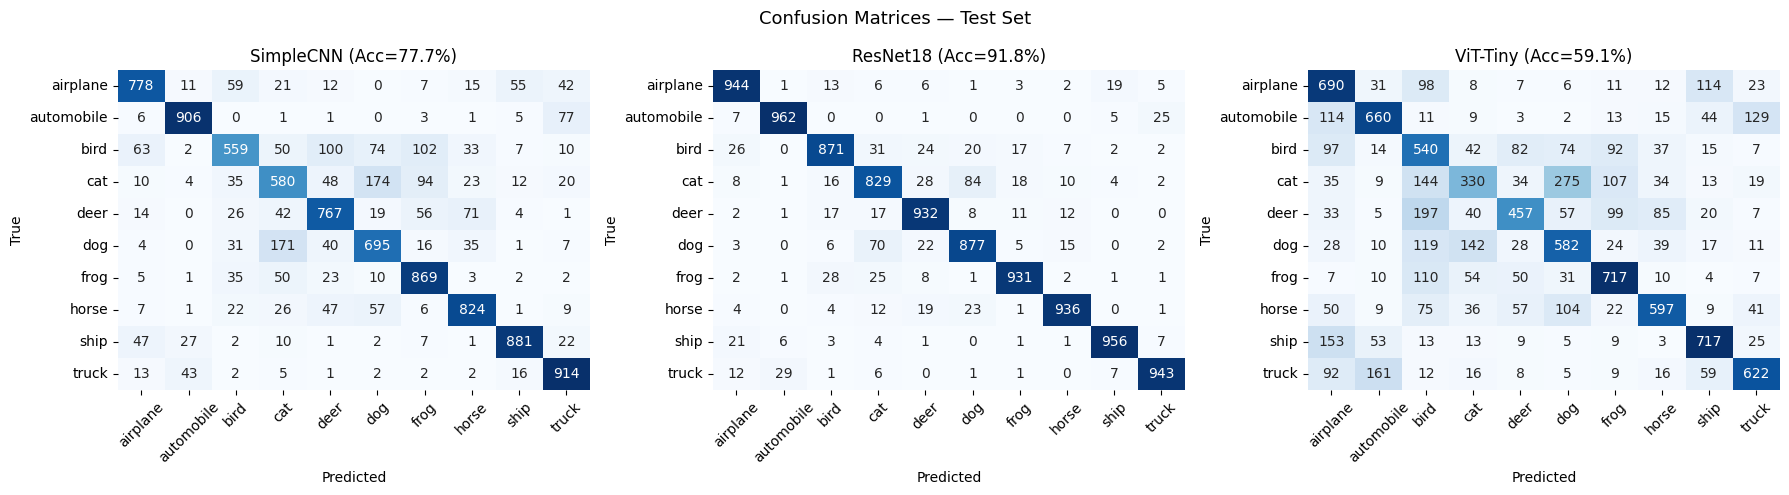

In [ ]:
# Confusion matrices for all three
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name} (Acc={100*res['accuracy']:.1f}%)")
    axes[idx].set_xlabel("Predicted"); axes[idx].set_ylabel("True")
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/confusion_matrices_comparison.png", dpi=150)
plt.show()

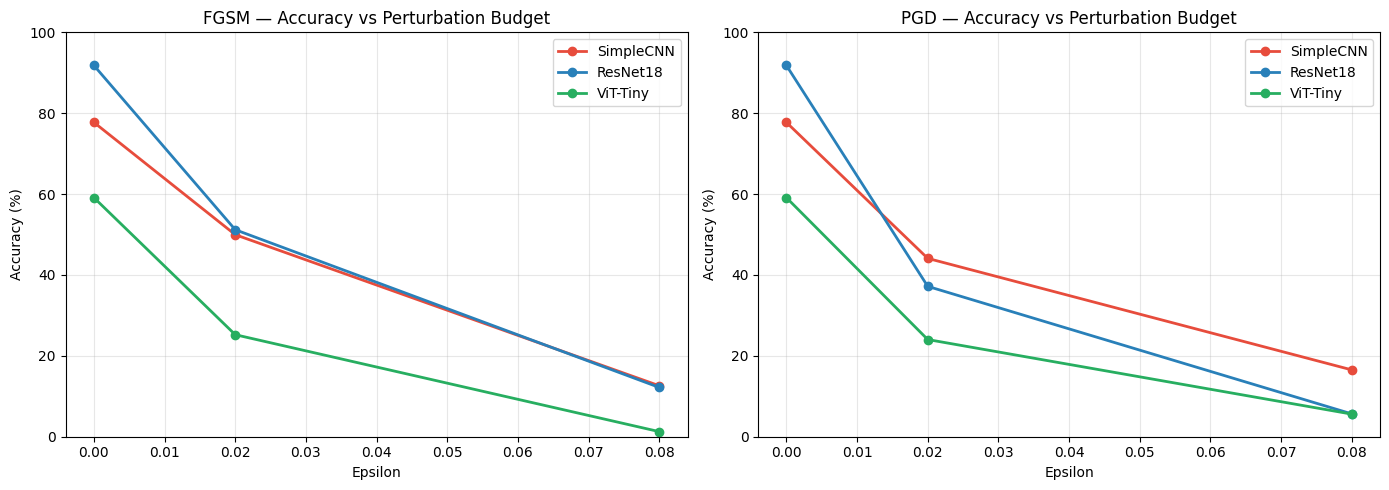

In [ ]:
# Adversarial accuracy comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for atk_idx, atk_name in enumerate(["fgsm", "pgd"]):
    for model_name, color in colors.items():
        clean = adv_results[model_name][(atk_name, EPSILONS[0])]["clean_acc"]
        accs = [clean] + [adv_results[model_name][(atk_name, e)]["adv_acc"] for e in EPSILONS]
        xs = [0] + EPSILONS
        axes[atk_idx].plot(xs, [a*100 for a in accs], marker='o', color=color,
                           linewidth=2, label=model_name)

    axes[atk_idx].set_xlabel("Epsilon")
    axes[atk_idx].set_ylabel("Accuracy (%)")
    axes[atk_idx].set_title(f"{atk_name.upper()} — Accuracy vs Perturbation Budget")
    axes[atk_idx].legend()
    axes[atk_idx].grid(alpha=0.3)
    axes[atk_idx].set_ylim(0, 100)

plt.tight_layout()
plt.savefig("outputs/plots/adversarial_accuracy_comparison.png", dpi=150)
plt.show()

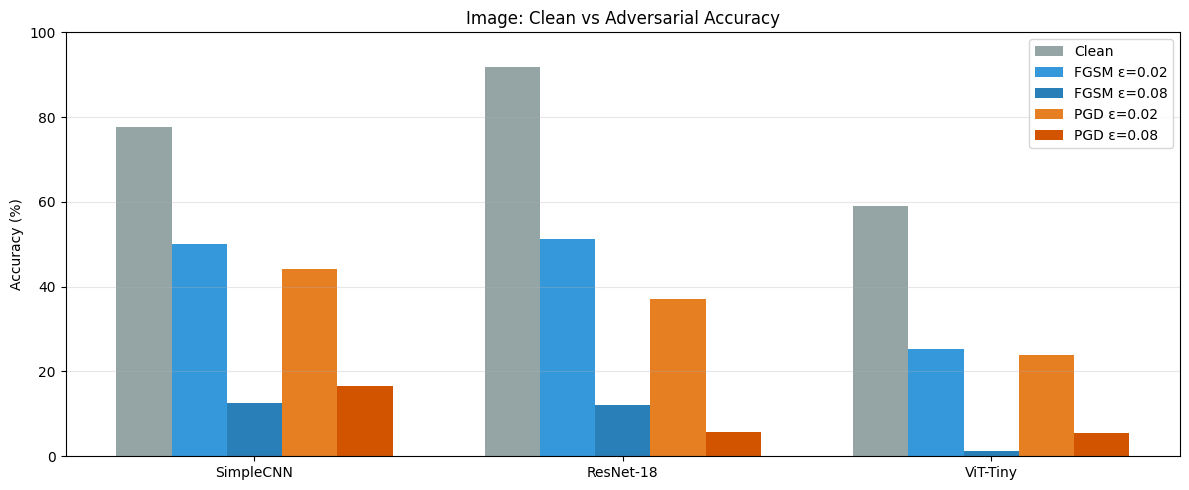

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data from results
models = ["SimpleCNN", "ResNet-18", "ViT-Tiny"]
clean_accs = [77.73, 91.81, 59.12]

fgsm_02 = [50.0, 51.2, 25.2]
fgsm_08 = [12.6, 12.2, 1.3]
pgd_02 = [44.1, 37.2, 24.0]
pgd_08 = [16.5, 5.7, 5.6]

x = np.arange(len(models))
w = 0.15

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 2*w, clean_accs, w, label="Clean", color="#95a5a6")
ax.bar(x - w, fgsm_02, w, label="FGSM ε=0.02", color="#3498db")
ax.bar(x, fgsm_08, w, label="FGSM ε=0.08", color="#2980b9")
ax.bar(x + w, pgd_02, w, label="PGD ε=0.02", color="#e67e22")
ax.bar(x + 2*w, pgd_08, w, label="PGD ε=0.08", color="#d35400")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Image: Clean vs Adversarial Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(0, 100)
plt.tight_layout()

plt.show()

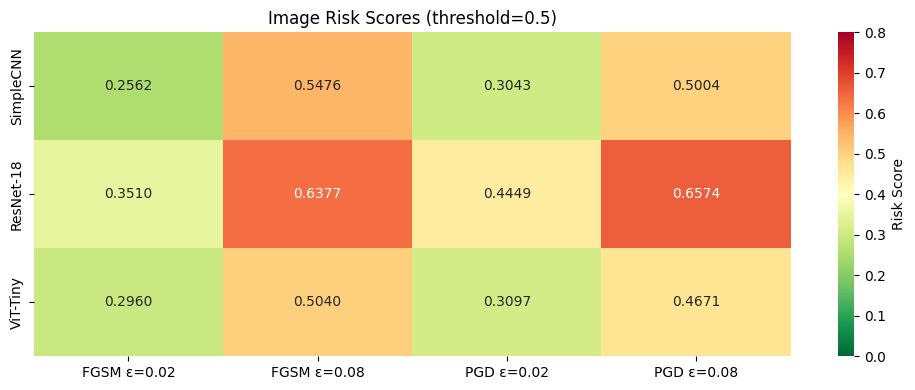

In [3]:
import seaborn as sns

models = ["SimpleCNN", "ResNet-18", "ViT-Tiny"]
attacks = ["FGSM ε=0.02", "FGSM ε=0.08", "PGD ε=0.02", "PGD ε=0.08"]
risk_matrix = np.array([
    [0.2562, 0.5476, 0.3043, 0.5004],
    [0.3510, 0.6377, 0.4449, 0.6574],
    [0.2960, 0.5040, 0.3097, 0.4671]
])

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(risk_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=attacks, yticklabels=models,
            vmin=0, vmax=0.8, ax=ax, cbar_kws={"label": "Risk Score"})
ax.set_title("Image Risk Scores (threshold=0.5)")
plt.tight_layout()

plt.show()